In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from matplotlib.ticker import (MultipleLocator,
                               FormatStrFormatter)

## Sistemas massa-mola

### Força harmônica prescrita: Sistema de 2 graus de liberdade excitado por uma força harmônica no 1° grau de liberdade

In [131]:
m1 = 10.0   #kg
m2 = 10.0   #kg
k1 = 10000.0   #N/m
k2 = 10000.0   #N/m
k3 = 10000.0   #N/m

In [120]:
# excitacao harmonica da forma F = [F1,0]*e^(iwt)
F1 = 10.0   #N
w = 30.0   #Hz
F = np.array([F1,0.0]) 

M = np.array([[m1,0.0],[0.0,m2]])
K = np.array([[k1+k3,-k3],[-k3,k2+k3]])

print("Matriz de massa")
print(M)
print("\nMatriz de rigidez")
print(K)
print("\nForça excitadora")
print(F)

# assumindo uma solucao Q = [Q1,Q2]*e^(iwt)

# matriz dinamica
M_inv = np.linalg.inv(M)
D = M_inv@K

print('\nMatriz dinâmica')
print(D)

# modos de vibração e frequencias naturais
autovalores, autovetores = np.linalg.eig(D)

f_naturais = autovalores**0.5
modos = autovetores

print('\nFrequências naturais e modos de vibração')
print(f_naturais)
print(modos)

# matriz de massa modal e matriz de rigidez modal (desacoplando o sistema)
modos_T = np.transpose(modos)

M_modal = modos_T@M@modos
K_modal = modos_T@K@modos
F_modal = modos_T@F

print('\nMassa modal')
print(M_modal)

print('\nRigidez modal')
print(K_modal)

print('\nForça excitadora em coordenadas modais')
print(F_modal)

# receptancia
Z = -w**2.0*M + K
R = np.linalg.inv(Z)

print('\nReceptância')
print(R)

# amplitude de resposta
Q = R@F

print('\nAmplitude de resposta')
print(Q)

Matriz de massa
[[10.  0.]
 [ 0. 10.]]

Matriz de rigidez
[[ 20000. -10000.]
 [-10000.  20000.]]

Força excitadora
[10.  0.]

Matriz dinâmica
[[ 2000. -1000.]
 [-1000.  2000.]]

Frequências naturais e modos de vibração
[54.77225575 31.6227766 ]
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

Massa modal
[[10.  0.]
 [ 0. 10.]]

Rigidez modal
[[30000.     0.]
 [    0. 10000.]]

Força excitadora em coordenadas modais
[7.07106781 7.07106781]

Receptância
[[0.00052381 0.00047619]
 [0.00047619 0.00052381]]

Amplitude de resposta
[0.0052381 0.0047619]


[0.00066667 0.00066681 0.00066723 0.00066793 0.00066892 0.00067019
 0.00067176 0.00067362 0.00067578 0.00067825 0.00068103 0.00068414
 0.00068758 0.00069136 0.0006955  0.0007     0.00070489 0.00071018
 0.00071589 0.00072204]


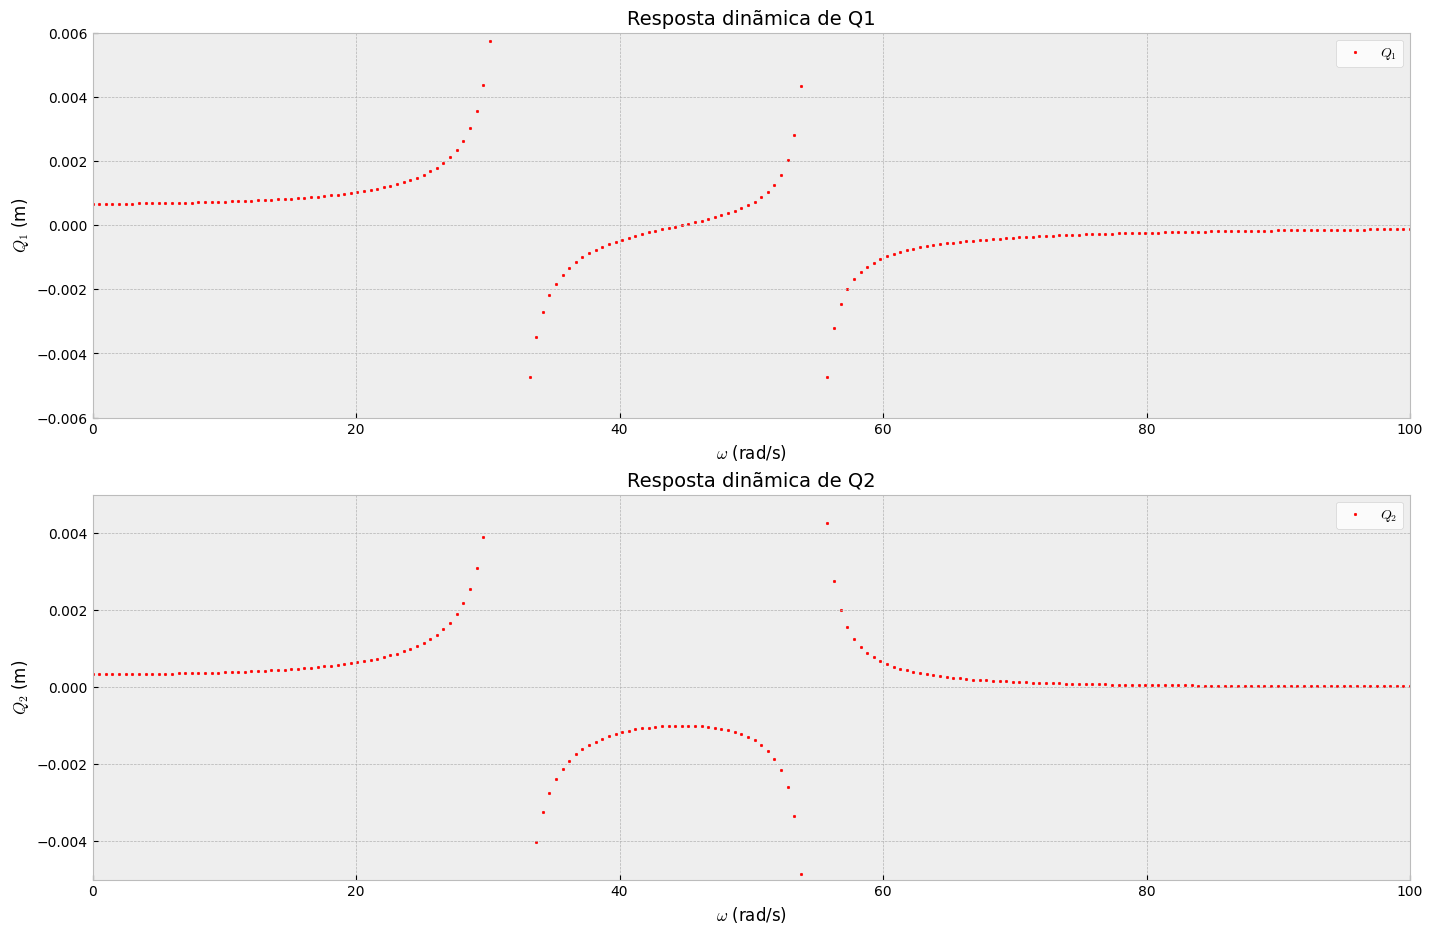

In [139]:
# excitacao harmonica da forma F = [F1,0]*e^(iwt)
F1_ex = 10.0
w_ex = np.linspace(0.0,100.0,200)
F_ex = np.array([F1_ex,0.0]) 

M_ex = np.array([[m1,0.0],[0.0,m2]])
K_ex = np.array([[k1+k3,-k3],[-k3,k2+k3]])

def R_din(w,M,K,F):
    Q_list = np.empty([len(w),2])
    for i in range(len(w)):
        Z = -w[i]**2.0*M + K
        R = np.linalg.inv(Z)

        Q = R@F
        Q_list[i] = Q

    return Q_list

Q_din = R_din(w_ex,M_ex,K_ex,F_ex)

print(Q_din[0:20,0])

# plot
plt.style.use('bmh')

fig1, ((ax1), (ax2)) = plt.subplots(2, sharey=False, sharex=False, figsize = (17,11))

#ax1.plot(wex,Q_din[:,0], color='red', linewidth=1.0, label=r'$Q_1$')
ax1.scatter(w_ex,Q_din[:,0], color='red', s=3.0, label=r'$Q_1$')
ax1.set_title('Resposta dinãmica de Q1',fontdict={'fontsize':14})
ax1.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax1.set_ylabel('$Q_1$ (m)',fontdict={'fontsize':12})
ax1.legend(loc='best',facecolor ='w')
ax1.set_xlim(w_ex[0],w_ex[-1])
ax1.set_ylim(-0.001*6.0,0.001*6.0)
ax1.yaxis.set_minor_locator(MultipleLocator(0.01))

#ax2.plot(wex,Q_din[:,1], color='red', linewidth=1.0, label=r'$Q_2$')
ax2.scatter(w_ex,Q_din[:,1], color='red', s=3.0, label=r'$Q_2$')
ax2.set_title('Resposta dinãmica de Q2',fontdict={'fontsize':14})
ax2.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax2.set_ylabel('$Q_2$ (m)',fontdict={'fontsize':12})
ax2.legend(loc='best',facecolor ='w')
ax2.set_xlim(w_ex[0],w_ex[-1])
ax2.set_ylim(-0.001*5.0,0.001*5.0)
ax2.yaxis.set_minor_locator(MultipleLocator(0.01))

plt.show()

### Deslocamento harmônico prescrito: edifício de 2 andares sujeito a deslocamento forçado em sua base

In [2]:
m1 = 10.0   #kg
m2 = 10.0   #kg
k1 = 10000.0   #N/m
k2 = 10000.0   #N/m

In [ ]:
# excitacao harmonica da forma Y = k1*[Y1,0]*e^(iwt)
Y1 = 0.01   #m
w = 10.0   #Hz
Y = np.array([Y1,0.0]) 

M = np.array([[m1,0.0],[0.0,m2]])
K = np.array([[k1+k2,-k2],[-k2,k2]])

print("Matriz de massa")
print(M)
print("\nMatriz de rigidez")
print(K)

# assumindo uma solucao Q = [Q1,Q2]*e^(iwt)

# matriz dinamica
M_inv = np.linalg.inv(M)
D = M_inv@K

print('\nMatriz dinâmica')
print(D)

# modos de vibração e frequencias naturais
autovalores, autovetores = np.linalg.eig(D)

f_naturais = autovalores**0.5
modos = autovetores

print('\nFrequências naturais e modos de vibração')
print(f_naturais)
print(modos)

# matriz de massa modal e matriz de rigidez modal (desacoplando o sistema)
modos_T = np.transpose(modos)

M_modal = modos_T@M@modos
K_modal = modos_T@K@modos

print('\nMassa modal')
print(M_modal)

print('\nRigidez modal')
print(K_modal)

# receptancia
Z = (-w**2.0*M + K)/k1
R = np.linalg.inv(Z)

print('\nReceptância')
print(R)

# amplitude de resposta
Q = R@Y

print('\nAmplitude de resposta')
print(Q)

Matriz de massa
[[10.  0.]
 [ 0. 10.]]

Matriz de rigidez
[[ 20000. -10000.]
 [-10000.  10000.]]

Matriz dinâmica
[[ 2000. -1000.]
 [-1000.  1000.]]

Frequências naturais e modos de vibração
[51.16672736 19.54395076]
[[ 0.85065081  0.52573111]
 [-0.52573111  0.85065081]]

Massa modal
[[10.  0.]
 [ 0. 10.]]

Rigidez modal
[[ 2.61803399e+04 -1.81898940e-12]
 [-2.04636308e-12  3.81966011e+03]]

Receptância
[[1.26760563 1.4084507 ]
 [1.4084507  2.67605634]]

Amplitude de resposta
[0.01267606 0.01408451]


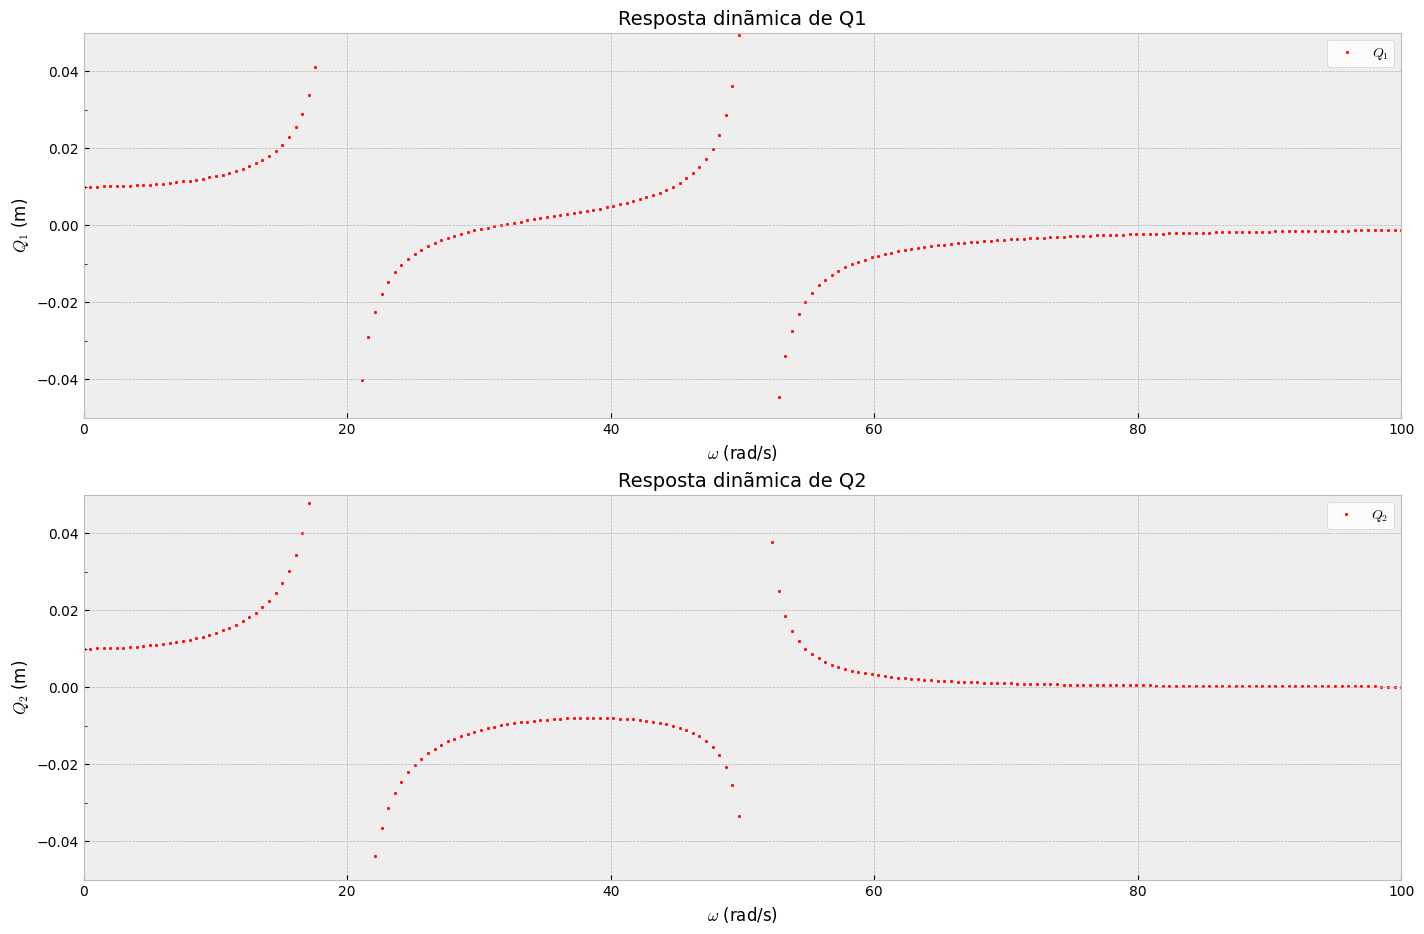

In [135]:
# excitacao harmonica da forma Y = k1*[Y1,0]*e^(iwt)
Y1_ex = 0.01   #m
w_ex = np.linspace(0.0,100.0,200)   #Hz
Y_ex = np.array([Y1_ex,0.0]) 

M_ex = np.array([[m1,0.0],[0.0,m2]])
K_ex = np.array([[k1+k2,-k2],[-k2,k2]])

def R_din(w,M,K,Y):
    Q_list = np.empty([len(w),2])
    for i in range(len(w)):
        Z = (-w[i]**2.0*M + K)/k1
        R = np.linalg.inv(Z)

        Q = R@Y
        Q_list[i] = Q

    return Q_list

Q_din = R_din(w_ex,M_ex,K_ex,Y_ex)

# plot
plt.style.use('bmh')

fig1, ((ax1), (ax2)) = plt.subplots(2, sharey=False, sharex=False, figsize = (17,11))

#ax1.plot(wex,Q_din[:,0], color='red', linewidth=1.0, label=r'$Q_1$')
ax1.scatter(w_ex,Q_din[:,0], color='red', s=3.0, label=r'$Q_1$')
ax1.set_title('Resposta dinãmica de Q1',fontdict={'fontsize':14})
ax1.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax1.set_ylabel('$Q_1$ (m)',fontdict={'fontsize':12})
ax1.legend(loc='best',facecolor ='w')
ax1.set_xlim(w_ex[0],w_ex[-1])
ax1.set_ylim(-Y1_ex*5.0,Y1_ex*5.0)
ax1.yaxis.set_minor_locator(MultipleLocator(0.01))

#ax2.plot(wex,Q_din[:,1], color='red', linewidth=1.0, label=r'$Q_2$')
ax2.scatter(w_ex,Q_din[:,1], color='red', s=3.0, label=r'$Q_2$')
ax2.set_title('Resposta dinãmica de Q2',fontdict={'fontsize':14})
ax2.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax2.set_ylabel('$Q_2$ (m)',fontdict={'fontsize':12})
ax2.legend(loc='best',facecolor ='w')
ax2.set_xlim(w_ex[0],w_ex[-1])
ax2.set_ylim(-Y1_ex*5.0,Y1_ex*5.0)
ax2.yaxis.set_minor_locator(MultipleLocator(0.01))

plt.show()

Note que o deslocamento de $Q_1$ zera por volta dos 32Hz para os valores de rigidez e massa dados. Se expandirmos a equação de $Q_1(\omega)$ presente em $Q = Z^{-1}Y$, veremos que $\left( \frac{k_2}{m_2} \right) ^{\frac{1}{2}}$ (no caso 31.62Hz) zera o movimento de $Q_1$.

Esses 2 exemplos são possíveis formas de se lidar com problemas de excitação. Recomenda-se o deslocamento prescrito para cenários altamente energéticos, onde o sistema estará com certeza se deslocando (como um edifício em um terremoto). Já para cenários de carga dinâmica onde um sistema pode vir a se movimentar a depender da amplitude e da frequência do esforço prescrito, recomenda-se a força prescrita.

### Absorvedor dinâmico sintonizado

Note que esse é um caso particular do 1° exemplo.

In [29]:
m1 = 1000.0   #kg
m2 = 250.0   #kg
#m2 = 0.01   #kg
k1 = 1000000.0   #N/m
k2 = 250000.0   #N/m
#k2 = 100000000000.0   #N/m

In [ ]:
# excitacao harmonica da forma F = [F1,0]*e^(iwt)
F1 = 500.0   #N
w = 30.0   #Hz
F = np.array([F1,0.0]) 

M = np.array([[m1,0.0],[0.0,m2]])
K = np.array([[k1+k2,-k2],[-k2,k2]])

print("Matriz de massa")
print(M)
print("\nMatriz de rigidez")
print(K)

# assumindo uma solucao Q = [Q1,Q2]*e^(iwt)

# matriz dinamica
M_inv = np.linalg.inv(M)
D = M_inv@K

print('\nMatriz dinâmica')
print(D)

# modos de vibração e frequencias naturais
autovalores, autovetores = np.linalg.eig(D)

f_naturais = autovalores**0.5
modos = autovetores

print('\nFrequências naturais e modos de vibração')
print(f_naturais)
print(modos)

# matriz de massa modal e matriz de rigidez modal (desacoplando o sistema)
modos_T = np.transpose(modos)

M_modal = modos_T@M@modos
K_modal = modos_T@K@modos

print('\nMassa modal')
print(M_modal)

print('\nRigidez modal')
print(K_modal)

# receptancia
Z = -w**2.0*M + K
R = np.linalg.inv(Z)

print('\nReceptância')
print(R)

# amplitude de resposta
Q = R@F

print('\nAmplitude de resposta')
print(Q)

Matriz de massa
[[1000.    0.]
 [   0.  250.]]

Matriz de rigidez
[[1250000. -250000.]
 [-250000.  250000.]]

Matriz dinâmica
[[ 1250.  -250.]
 [-1000.  1000.]]

Frequências naturais e modos de vibração
[40.50170618 24.69031788]
[[ 0.5392856   0.36365914]
 [-0.84212294  0.93153209]]

Massa modal
[[4.68121716e+02 2.84217094e-14]
 [2.84217094e-14 3.49185977e+02]]

Rigidez modal
[[7.67901340e+05 5.82076609e-11]
 [7.27595761e-11 2.12867891e+05]]

Receptância
[[-4.65116279e-07 -4.65116279e-06]
 [-4.65116279e-06 -6.51162791e-06]]

Amplitude de resposta
[-0.00023256 -0.00232558]


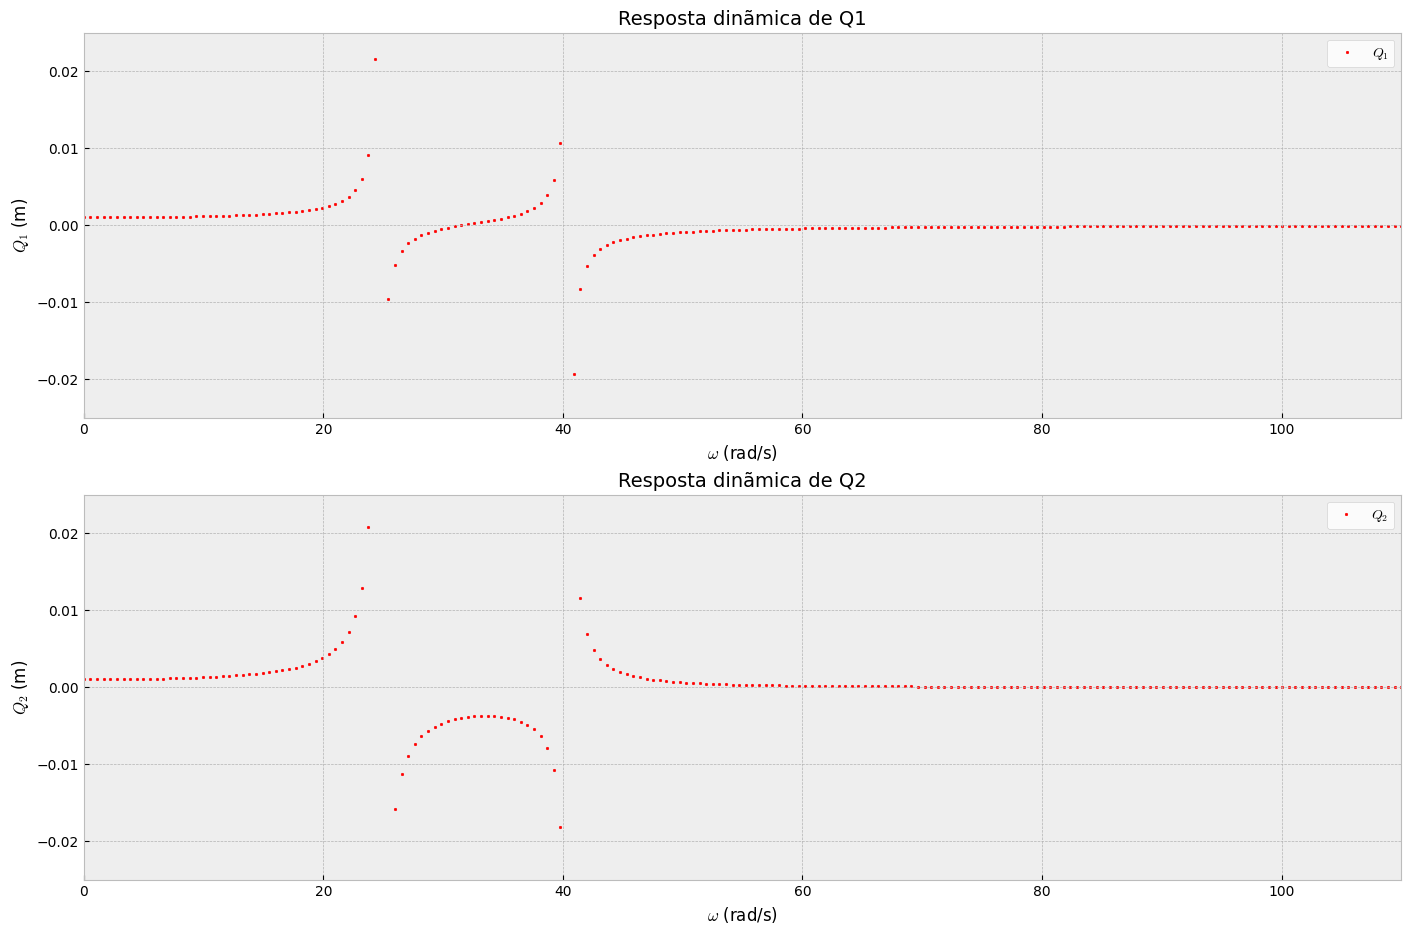

In [28]:
# excitacao harmonica da forma F = [F1,0]*e^(iwt)
F1_ex = 1000.0   #N
w_ex = np.linspace(0.0,110.0,200)   #Hz
F_ex = np.array([F1_ex,0.0])

M_ex = np.array([[m1,0.0],[0.0,m2]])
K_ex = np.array([[k1+k2,-k2],[-k2,k2]])

def R_din(w,M,K,F):
    Q_list = np.empty([len(w),2])
    for i in range(len(w)):
        Z = (-w[i]**2.0*M + K)
        R = np.linalg.inv(Z)

        Q = R@F
        Q_list[i] = Q

    return Q_list

Q_din = R_din(w_ex,M_ex,K_ex,F_ex)

# plot
plt.style.use('bmh')

fig1, ((ax1), (ax2)) = plt.subplots(2, sharey=False, sharex=False, figsize = (17,11))

#ax1.plot(wex,Q_din[:,0], color='red', linewidth=1.0, label=r'$Q_1$')
ax1.scatter(w_ex,Q_din[:,0], color='red', s=3.0, label=r'$Q_1$')
ax1.set_title('Resposta dinãmica de Q1',fontdict={'fontsize':14})
ax1.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax1.set_ylabel('$Q_1$ (m)',fontdict={'fontsize':12})
ax1.legend(loc='best',facecolor ='w')
ax1.set_xlim(w_ex[0],w_ex[-1])
ax1.set_ylim(-0.005*5,0.005*5)
ax1.yaxis.set_minor_locator(MultipleLocator(0.01))

#ax2.plot(wex,Q_din[:,1], color='red', linewidth=1.0, label=r'$Q_2$')
ax2.scatter(w_ex,Q_din[:,1], color='red', s=3.0, label=r'$Q_2$')
ax2.set_title('Resposta dinãmica de Q2',fontdict={'fontsize':14})
ax2.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax2.set_ylabel('$Q_2$ (m)',fontdict={'fontsize':12})
ax2.legend(loc='best',facecolor ='w')
ax2.set_xlim(w_ex[0],w_ex[-1])
ax2.set_ylim(-0.005*5,0.005*5)
ax2.yaxis.set_minor_locator(MultipleLocator(0.01))

plt.show()

É interessante inserir um absorvedor dinâmico sintonizado em seu sistema quando a frequência de excitação do sistema se aproxima ou é próxima da ressonância do sistema. No exemplo acima, a frequência de excitação é de 30 Hz, bem perto da frequência de ressonância do sistema caso a massa principal estivesse isolada (experimente usar um valor bem alto em $k_2$ e uma valor tendendo a 0 em $m_2$ para emular um sistema de 1 grau de liberdade e veja sua 1ª ressonância, será próxima de 32Hz para $m_1=1000kg$ e $k_1=10^6N/m$).

O absorvedor dinâmico sintonizado é inserido no sistema para vibrar no lugar da massa principal, deixando-a estável ainda que a força excitadora atue diretamente nela. Viu-se no exemplo anterior que quando a freqência de excitação se iguala à raíz da rigidez pela massa do 2° corpo, o 1° corpo deixa de se deslocar. Como nessa situação tem-se a frequência de excitação e deseja-se modelar o absorvedor, define-se uma rigidez e uma massa para o absorvedor que seja compatível com a frequência de excitação. 

$$ \sqrt{\frac{k_2}{m_2}} = \omega_e$$

Adicionando o absorvedor ao sistema, a 1ª ressonância do sistema é deslocada e o sistema passa a operar numa faixa estável entre as ressonâncias, onde a massa principal fica estável e o absorvedor passa a vibrar pelo sistema inteiro. Caso se queira aumentar essa faixa segura entre as ressonâncias, é preciso aumentar a rigidez e a massa do absorvedor (desde que se conserve a razão entre elas).

## Sistemas massa-mola-amortecedor

Os sistemas massa-mola-amortecedor são caracterizados por terem parte complexa em sua matriz dinâmica, sendo sua receptância, portanto, também complexa. Em sistemas de 1 grau de liberdade, basta extrair a norma desse número complexo para se ter a resposta dinâmica do sistema.

$$|Q| = \frac{1}{|Z|} |F|$$

Já em sistemas de N graus de liberdade, não há como interpretar a resposta dinâmica do sistema pois a receptância se torna uma matriz de elementos complexos, cujo determinante também será complexo. Uma solução para esse problema seria desacoplar os graus de liberdade do sistema, passando a análise para o espaço modal; assim o sistema de N GL's se tornaria N sistemas de um 1 GL. 

$$ \overline{M} = \Phi^T M \Phi \,\,,\,\,\, \overline{K} = \Phi^T K \Phi$$

Onde $\Phi$ é a base de autovetores do sistema não amortecido e $\overline{M}$ e $\overline{K}$ são as matrizes de massa e rigidez modal. Aí esbarramos em outro problema: a matriz de amortecimento não é diagonalizável, uma vez que os autovalores e autovetores do sistema são obtidos desconsiderando o amortecimento do sistema. Uma solução para esse problema é aproximar a matriz de amortecimento por uma combinação linear das matrizes de massa e rigidez. A matriz de amortecimento seria, portanto, diagonalizável.

$$ C \approx \alpha M + \beta K $$

Onde $\alpha$ e $\beta$ são definidos por inspeção ou otimização. Dessa maneira, a receptância do sistema já transformado para coordenadas modais será:

$$ Z = (-\omega^2 + \alpha \omega j) \overline{M} + (1 + \beta \omega j) \overline{K} $$

Note que a receptância continuará sendo uma matriz complexa, mas agora diagonal, o que torna possível encarar o problema como N sistemas de um 1 GL.

### 1 GL

In [101]:
m1 = 10.0   #kg
k1 = 10000.0   #N/m
c1 = 50.0   #kg/s
c2 = 100.0
c3 = 150.0
c4 = 200.0
c5 = 250.0

In [102]:
F = 50.0   #N
w = 30   #Hz

M = m1
K = k1
C = c5

print("Matriz de massa")
print(M)
print("\nMatriz de rigidez")
print(K)
print("\nMatriz de amortecimento")
print(C)

# frequencias naturais
w_n = (K/M)**(0.5)   #Hz
ksi = C/(2*M*w_n)
w_a = (1.0-ksi**2.0)**(0.5)*w_n   #Hz

print("\nFator de amortecimento")
print(ksi)

print('\nFrequência natural e amortecida')
print("{}Hz e {}Hz".format(w_n,w_a))

# FRF
Z = -w**2.0*M + w*C*1j + K
H = np.linalg.norm(Z)**(-1.0)

print('\nFRF')
print(H)

# amplitude de resposta
Q = H*F

print('\nAmplitude de resposta')
print(Q)

Matriz de massa
10.0

Matriz de rigidez
10000.0

Matriz de amortecimento
250.0

Fator de amortecimento
0.39528470752104744

Frequência natural e amortecida
31.622776601683793Hz e 29.047375096555626Hz

FRF
0.00013216372009101796

Amplitude de resposta
0.006608186004550898


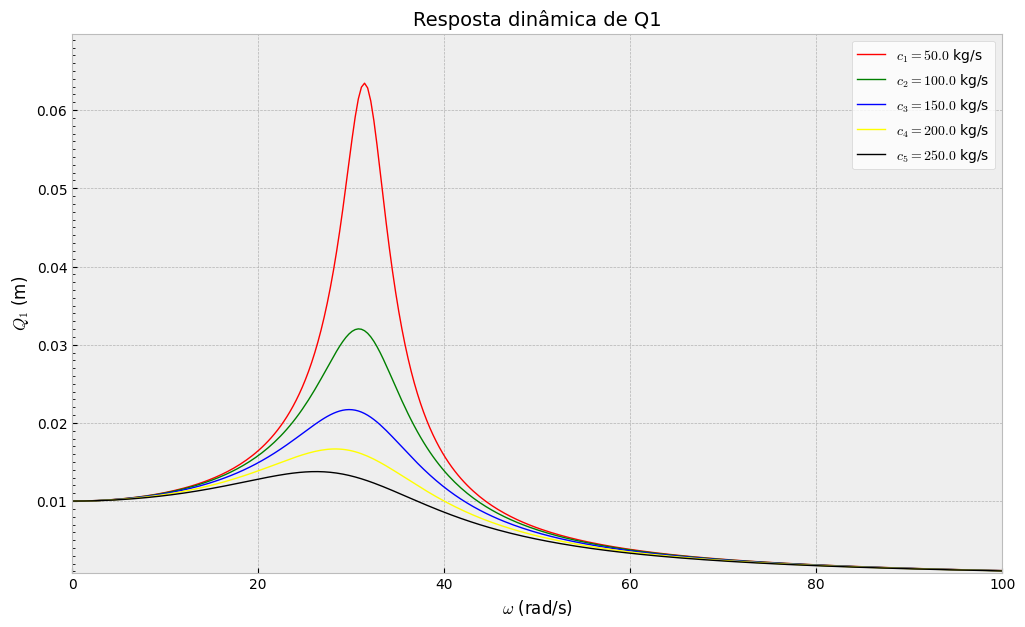

In [ ]:
F_ex = 100.0
w_ex = np.linspace(0.0,100.0,300) 

M_ex = m1
K_ex = k1
C_ex1 = c1
C_ex2 = c2
C_ex3 = c3
C_ex4 = c4
C_ex5 = c5

def R_din(w,M,C,K,F):
    Q_list = np.empty(len(w))
    for i in range(len(w)):
        Z = -w[i]**2.0*M + w[i]*C*1j + K
        R = np.linalg.norm(Z)**(-1.0)

        Q = R*F
        Q_list[i] = Q

    return Q_list

Q_c1 = R_din(w_ex,M_ex,C_ex1,K_ex,F_ex)
Q_c2 = R_din(w_ex,M_ex,C_ex2,K_ex,F_ex)
Q_c3 = R_din(w_ex,M_ex,C_ex3,K_ex,F_ex)
Q_c4 = R_din(w_ex,M_ex,C_ex4,K_ex,F_ex)
Q_c5 = R_din(w_ex,M_ex,C_ex5,K_ex,F_ex)

# plot
plt.style.use('bmh')

fig1, ax1 = plt.subplots(1, sharey=False, sharex=False, figsize = (12,7))

ax1.plot(w_ex,Q_c1, color='red', linewidth=1.0, label=r'$c_1 = {}$ kg/s'.format(C_ex1))
ax1.plot(w_ex,Q_c2, color='green', linewidth=1.0, label=r'$c_2 = {}$ kg/s'.format(C_ex2))
ax1.plot(w_ex,Q_c3, color='blue', linewidth=1.0, label=r'$c_3 = {}$ kg/s'.format(C_ex3))
ax1.plot(w_ex,Q_c4, color='yellow', linewidth=1.0, label=r'$c_4 = {}$ kg/s'.format(C_ex4))
ax1.plot(w_ex,Q_c5, color='black', linewidth=1.0, label=r'$c_5 = {}$ kg/s'.format(C_ex5))
#ax1.scatter(w_ex,Q_din, color='red', s=3.0, label=r'$Q_1$')
ax1.set_title('Resposta dinâmica de Q1',fontdict={'fontsize':14})
ax1.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax1.set_ylabel('$Q_1$ (m)',fontdict={'fontsize':12})
ax1.legend(loc='best',facecolor ='w')
ax1.set_xlim(w_ex[0],w_ex[-1])
ax1.set_ylim(min(Q_c5)*0.8,max(Q_c1)*1.1)
ax1.yaxis.set_minor_locator(MultipleLocator(0.001))
plt.show()

### 2 GL's

In [37]:
m1 = 10.0   #kg
m2 = 10.0   #kg
k1 = 10000.0   #N/m
k2 = 10000.0   #N/m
k3 = 10000.0   #N/m
c1 = 100   #kg/s
c2 = 100   #kg/s
c3 = 100   #kg/s
c4 = 10   #kg/s
c5 = 10   #kg/s
c6 = 10   #kg/s

In [ ]:
# excitacao harmonica da forma F = [F1,0]*e^(iwt)
F1 = 10.0   #N
w = 30.0   #Hz
F = np.array([F1,0.0]) 

M = np.array([[m1,0.0],[0.0,m2]])
K = np.array([[k1+k3,-k3],[-k3,k2+k3]])
C = np.array([[c1+c3,-c3],[-c3,c2+c3]])

print("Matriz de massa")
print(M)
print("\nMatriz de rigidez")
print(K)
print("\nMatriz de amortecimento")
print(C)
print('\nForça excitadora')
print(F)

# fator de amortecimento
## obtido experimentalmente pelo ajuste de uma curva e seu decremento logaritmico
## Como a matriz de amortecimento do sistema esta disponivel, e possivel obter alpha e beta sem usar ksi
#ksi = 0.2

# construindo uma matriz de amortecimento proporcional
def RMSE(x : list,*args : tuple):
    SE = (args[2] - (x[0]*args[0] + x[1]*args[1]))**2.0
    RMSE = (np.sum(SE)/SE.size)**0.5
    return RMSE

#print(RMSE([0.007,0.01],M,K,C))   #example

optimization = optimize.differential_evolution(
               func=RMSE,
               bounds=optimize.Bounds([0.001,0.0001],[100.0,100.0]),
               args=(M,K,C),
               #x0=[100.0,0.001],
               maxiter=100,
               tol=0.001,
               #polish=False,
               #popsize=20,
               #disp=True
               )

alpha, beta = optimization.x
RMSE_final_value = optimization.fun
print("\nalpha: {}\nbeta: {}".format(alpha,beta))
print("\nRMSE: {}".format(RMSE_final_value))

Cp = alpha*M + beta*K

print("\nMatriz de amortecimento proporcional: ")
print(Cp)

# assumindo uma solucao Q = [Q1,Q2]*e^(i(wt + p))

# matriz dinamica
M_inv = np.linalg.inv(M)
D = M_inv@K

# modos de vibração e frequencias naturais
autovalores, autovetores = np.linalg.eig(D)

f_naturais = autovalores**0.5
modos = autovetores

print('\nFrequências naturais e modos de vibração')
print(f_naturais)
print(modos)

# matriz de massa modal e matriz de rigidez modal (desacoplando o sistema)
modos_T = np.transpose(modos)

M_modal = modos_T@M@modos
K_modal = modos_T@K@modos
Cp_modal = modos_T@Cp@modos
F_modal = modos_T@F

print('\nMassa modal')
print(M_modal)

print('\nRigidez modal')
print(K_modal)

print('\nAmortecimento modal')
print(Cp_modal)

print('\nForça excitadora em coordenadas modais')
print(F_modal)

# agora que sistema esta desacoplado, sera calculada a receptancia para cada GL
Z = np.empty(M_modal.shape[0])
for i in range(M_modal.shape[0]):
    Z[i] = np.linalg.norm(-w**2.0*M_modal[i,i] + w*Cp_modal[i,i]*1j + K_modal[i,i])

R = Z**(-1.0)

print('\nReceptâncias')
print(R)

# amplitude de resposta
Q_modal = R*F_modal

print('\nAmplitudes de resposta em coordenadas modais')
print(Q_modal)

Q = modos@Q_modal

print('\nAmplitudes de resposta')
print(Q)

Matriz de massa
[[10.  0.]
 [ 0. 10.]]

Matriz de rigidez
[[ 20000. -10000.]
 [-10000.  20000.]]

Matriz de amortecimento
[[ 200 -100]
 [-100  200]]

Força excitadora
[10.  0.]

alpha: 0.001000012659979177
beta: 0.009999597864599252

RMSE: 0.0031624970806045085

Matriz de amortecimento proporcional: 
[[200.00195742 -99.99597865]
 [-99.99597865 200.00195742]]

Frequências naturais e modos de vibração
[54.77225575 31.6227766 ]
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

Massa modal
[[10.  0.]
 [ 0. 10.]]

Rigidez modal
[[30000.     0.]
 [    0. 10000.]]

Amortecimento modal
[[299.99793606   0.        ]
 [  0.         100.00597877]]

Força excitadora em coordenadas modais
[7.07106781 7.07106781]

Receptâncias
[4.37688577e-05 3.16210751e-04]

Amplitudes de resposta em coordenadas modais
[0.00030949 0.00223595]

Amplitudes de resposta
[0.0017999  0.00136221]



alpha: 0.0010002039753800318
beta: 0.009999599776740808

RMSE: 0.003162923480135013

Matriz de amortecimento proporcional: 
[[200.00198746 -99.99599369   0.           0.        ]
 [-99.99599369 200.00198746 -99.99599369   0.        ]
 [  0.         -99.99599369 200.00198746 -99.99599369]
 [  0.           0.         -99.99599369 200.00198746]]

alpha: 0.001000044603358674
beta: 0.0009996004145449433

RMSE: 0.0031624260981947586

Matriz de amortecimento proporcional: 
[[20.00194881 -9.99597396  0.          0.        ]
 [-9.99597396 20.00194881 -9.99597396  0.        ]
 [ 0.         -9.99597396 20.00194881 -9.99597396]
 [ 0.          0.         -9.99597396 20.00194881]]

Frequências naturais e modos de vibração
[54.77225575 31.6227766 ]
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


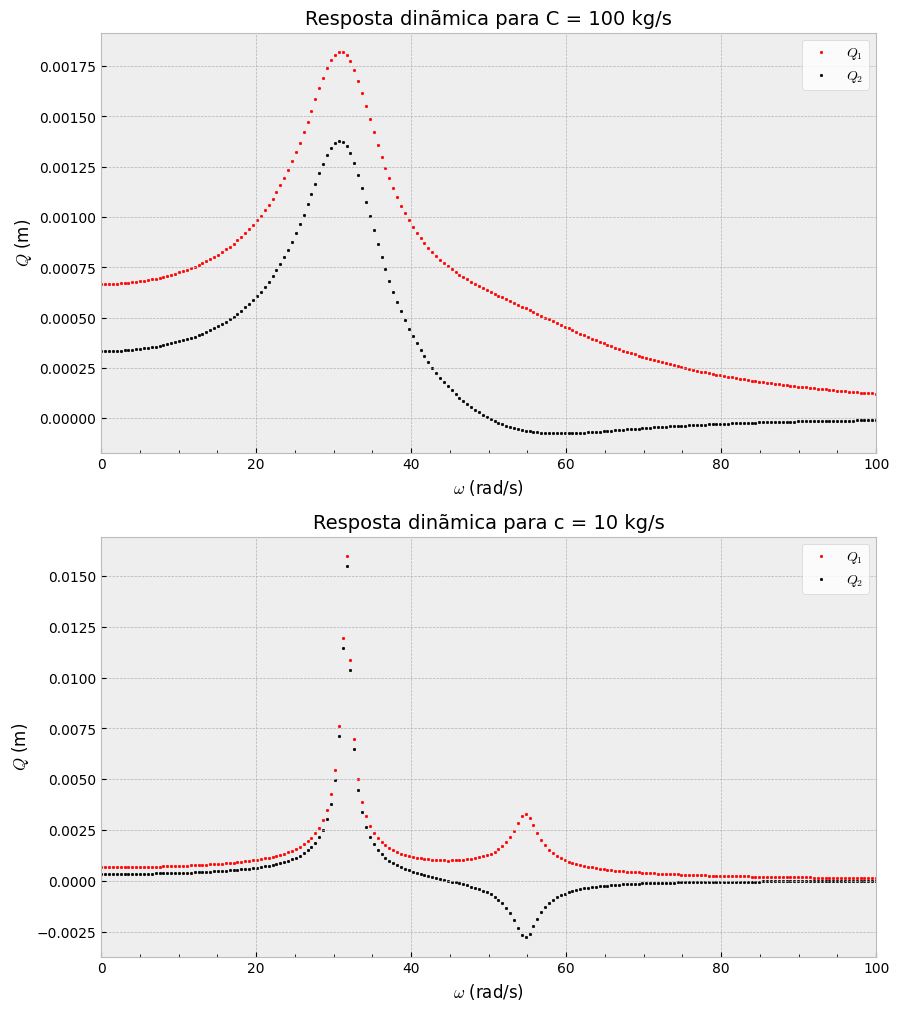

In [ ]:
# excitacao harmonica da forma F = [F1,0]*e^(iwt)
F1_ex = 10.0
w_ex = np.linspace(0.0,100.0,200)
F_ex = np.array([F1_ex,0.0])

M_ex = np.array([[m1,0.0],[0.0,m2]])
K_ex = np.array([[k1+k3,-k3],[-k3,k2+k3]])
C1_ex = np.array([[c1+c3,-c3],[-c3,c2+c3]])
C2_ex = np.array([[c4+c6,-c6],[-c6,c5+c6]])

# construindo uma matriz de amortecimento proporcional
def RMSE(x : list,*args : tuple):
    SE = (args[2] - (x[0]*args[0] + x[1]*args[1]))**2.0
    RMSE = (np.sum(SE)/SE.size)**0.5
    return RMSE

#print(RMSE([0.007,0.01],M,K,C))   #example

optimization1 = optimize.differential_evolution(
               func=RMSE,
               bounds=optimize.Bounds([0.001,0.0001],[100.0,100.0]),
               args=(M_ex,K_ex,C1_ex),
               #x0=[100.0,0.001],
               maxiter=100,
               tol=0.001,
               #polish=False,
               #popsize=20,
               #disp=True
               )

optimization2 = optimize.differential_evolution(
               func=RMSE,
               bounds=optimize.Bounds([0.001,0.0001],[100.0,100.0]),
               args=(M_ex,K_ex,C2_ex),
               #x0=[100.0,0.001],
               maxiter=100,
               tol=0.001,
               #polish=False,
               #popsize=20,
               #disp=True
               )

alpha1, beta1 = optimization1.x
RMSE_final_value1 = optimization1.fun
print("\nalpha: {}\nbeta: {}".format(alpha1,beta1))
print("\nRMSE: {}".format(RMSE_final_value1))

Cp1_ex = alpha1*M_ex + beta1*K_ex

print("\nMatriz de amortecimento proporcional: ")
print(Cp1_ex)

alpha2, beta2 = optimization2.x
RMSE_final_value2 = optimization2.fun
print("\nalpha: {}\nbeta: {}".format(alpha2,beta2))
print("\nRMSE: {}".format(RMSE_final_value2))

Cp2_ex = alpha2*M_ex + beta2*K_ex

print("\nMatriz de amortecimento proporcional: ")
print(Cp2_ex)

# assumindo uma solucao Q = [Q1,Q2]*e^(i(wt + p))

# matriz dinamica
M_ex_inv = np.linalg.inv(M_ex)
D_ex = M_ex_inv@K_ex

# modos de vibração e frequencias naturais
autovalores, autovetores = np.linalg.eig(D_ex)

f_naturais = autovalores**0.5
modos = autovetores

print('\nFrequências naturais e modos de vibração')
print(f_naturais)
print(modos)

# matriz de massa modal e matriz de rigidez modal (desacoplando o sistema)
modos_T = np.transpose(modos)

M_modal = modos_T@M_ex@modos
K_modal = modos_T@K_ex@modos
Cp1_modal = modos_T@Cp1_ex@modos
Cp2_modal = modos_T@Cp2_ex@modos
F_modal = modos_T@F_ex

def R_din(w,M_modal,Cp_modal,K_modal,F_modal):
    Q = np.empty([w.size,M_modal.shape[0]])
    for i in range(w.size):
        Z = np.empty(M_modal.shape[0])
        for j in range(M_modal.shape[0]):
            Z[j] = np.linalg.norm(-w[i]**2.0*M_modal[j,j] + w[i]*Cp_modal[j,j]*1j + K_modal[j,j])
        
        R = Z**(-1.0)
        Q_modal = R*F_modal
        Q[i,:] = modos@Q_modal

    return Q

Q_din_C1 = R_din(w_ex,M_modal,Cp1_modal,K_modal,F_modal)
Q_din_C2 = R_din(w_ex,M_modal,Cp2_modal,K_modal,F_modal)

# plot
plt.style.use('bmh')

fig1, ((ax1),(ax2)) = plt.subplots(2,1, sharey=False, sharex=False, figsize = (10,12))

#ax1.plot(wex,Q_din[:,0], color='red', linewidth=1.0, label=r'$Q_1$')
ax1.scatter(w_ex,Q_din_C1[:,0], color='red', s=3.0, label=r'$Q_1$')
ax1.scatter(w_ex,Q_din_C1[:,1], color='black', s=3.0, label=r'$Q_2$')
ax1.set_title('Resposta dinãmica para C = {} kg/s'.format(c1),fontdict={'fontsize':14})
ax1.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax1.set_ylabel('$Q$ (m)',fontdict={'fontsize':12})
ax1.legend(loc='best',facecolor ='w')
ax1.set_xlim(w_ex[0],w_ex[-1])
#ax1.set_ylim(min(Q_din[:,0])*0.8,max(Q_din[:,0])*1.1)
ax1.xaxis.set_minor_locator(MultipleLocator(5))
ax1.yaxis.set_minor_locator(MultipleLocator(0.01))

ax2.scatter(w_ex,Q_din_C2[:,0], color='red', s=3.0, label=r'$Q_1$')
ax2.scatter(w_ex,Q_din_C2[:,1], color='black', s=3.0, label=r'$Q_2$')
ax2.set_title('Resposta dinãmica para c = {} kg/s'.format(c4),fontdict={'fontsize':14})
ax2.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax2.set_ylabel('$Q$ (m)',fontdict={'fontsize':12})
ax2.legend(loc='best',facecolor ='w')
ax2.set_xlim(w_ex[0],w_ex[-1])
#ax2.set_ylim(min(Q_din[:,0])*0.8,max(Q_din[:,0])*1.1)
ax2.xaxis.set_minor_locator(MultipleLocator(5))
ax2.yaxis.set_minor_locator(MultipleLocator(0.01))


plt.show()

### 4 GL's

In [42]:
m1 = 10.0   #kg
m2 = 10.0   #kg
m3 = 10.0   #kg
m4 = 10.0   #kg
k1 = 10000.0   #N/m
k2 = 10000.0   #N/m
k3 = 10000.0   #N/m
k4 = 10000.0   #N/m
k5 = 10000.0   #N/m
c1 = 100   #kg/s
c2 = 100   #kg/s
c3 = 100   #kg/s
c4 = 100   #kg/s
c5 = 100   #kg/s
c6 = 10   #kg/s
c7 = 10   #kg/s
c8 = 10   #kg/s
c9 = 10   #kg/s
c10 = 10   #kg/s

In [43]:
# excitacao harmonica da forma F = [F1,0]*e^(iwt)
F1 = 10.0   #N
w = 30.0   #Hz
F = np.array([F1,0.0,0.0,0.0]) 

M = np.array([[m1,0.0,0.0,0.0],[0.0,m2,0.0,0.0],[0.0,0.0,m3,0.0],[0.0,0.0,0.0,m4]])
K = np.array([[k1+k2,-k2,0.0,0.0],[-k2,k2+k3,-k3,0.0],[0.0,-k3,k3+k4,-k4],[0.0,0.0,-k4,k4+k5]])
C = np.array([[c1+c2,-c2,0.0,0.0],[-c2,c3+c2,-c3,0.0],[0.0,-c3,c3+c4,-c4],[0.0,0.0,-c4,c4+c5]])

print("Matriz de massa")
print(M)
print("\nMatriz de rigidez")
print(K)
print("\nMatriz de amortecimento")
print(C)
print('\nForça excitadora')
print(F)

# fator de amortecimento
## obtido experimentalmente pelo ajuste de uma curva e seu decremento logaritmico
## Como a matriz de amortecimento do sistema esta disponivel, e possivel obter alpha e beta sem usar ksi
#ksi = 0.2

# construindo uma matriz de amortecimento proporcional
def RMSE(x : list,*args : tuple):
    SE = (args[2] - (x[0]*args[0] + x[1]*args[1]))**2.0
    RMSE = (np.sum(SE)/SE.size)**0.5
    return RMSE

#print(RMSE([0.007,0.01],M,K,C))   #example

optimization = optimize.differential_evolution(
               func=RMSE,
               bounds=optimize.Bounds([0.001,0.0001],[100.0,100.0]),
               args=(M,K,C),
               #x0=[100.0,0.001],
               maxiter=100,
               tol=0.001,
               #polish=False,
               #popsize=20,
               #disp=True
               )

alpha, beta = optimization.x
RMSE_final_value = optimization.fun
print("\nalpha: {}\nbeta: {}".format(alpha,beta))
print("\nRMSE: {}".format(RMSE_final_value))

Cp = alpha*M + beta*K

print("\nMatriz de amortecimento proporcional: ")
print(Cp)

# assumindo uma solucao Q = [Q1,Q2]*e^(i(wt + p))

# matriz dinamica
M_inv = np.linalg.inv(M)
D = M_inv@K

# modos de vibração e frequencias naturais
autovalores, autovetores = np.linalg.eig(D)

f_naturais = autovalores**0.5
modos = autovetores

print('\nFrequências naturais e modos de vibração')
print(f_naturais)
print(modos)

# matriz de massa modal e matriz de rigidez modal (desacoplando o sistema)
modos_T = np.transpose(modos)

M_modal = modos_T@M@modos
K_modal = modos_T@K@modos
Cp_modal = modos_T@Cp@modos
F_modal = modos_T@F

print('\nMassa modal')
print(M_modal)

print('\nRigidez modal')
print(K_modal)

print('\nAmortecimento modal')
print(Cp_modal)

print('\nForça excitadora em coordenadas modais')
print(F_modal)

# agora que sistema esta desacoplado, sera calculada a receptancia para cada GL
Z = np.empty(M_modal.shape[0])
for i in range(M_modal.shape[0]):
    Z[i] = np.linalg.norm(-w**2.0*M_modal[i,i] + w*Cp_modal[i,i]*1j + K_modal[i,i])

R = Z**(-1.0)

print('\nReceptâncias')
print(R)

# amplitude de resposta
Q_modal = R*F_modal

print('\nAmplitudes de resposta em coordenadas modais')
print(Q_modal)

Q = modos@Q_modal

print('\nAmplitudes de resposta')
print(Q)

Matriz de massa
[[10.  0.  0.  0.]
 [ 0. 10.  0.  0.]
 [ 0.  0. 10.  0.]
 [ 0.  0.  0. 10.]]

Matriz de rigidez
[[ 20000. -10000.      0.      0.]
 [-10000.  20000. -10000.      0.]
 [     0. -10000.  20000. -10000.]
 [     0.      0. -10000.  20000.]]

Matriz de amortecimento
[[ 200. -100.    0.    0.]
 [-100.  200. -100.    0.]
 [   0. -100.  200. -100.]
 [   0.    0. -100.  200.]]

Força excitadora
[10.  0.  0.  0.]

alpha: 0.0010000533878482543
beta: 0.009999637034255215

RMSE: 0.0026113167796508845

Matriz de amortecimento proporcional: 
[[200.00274122 -99.99637034   0.           0.        ]
 [-99.99637034 200.00274122 -99.99637034   0.        ]
 [  0.         -99.99637034 200.00274122 -99.99637034]
 [  0.           0.         -99.99637034 200.00274122]]

Frequências naturais e modos de vibração
[60.1500955  51.16672736 19.54395076 37.17480345]
[[-0.37174803 -0.60150096 -0.37174803 -0.60150096]
 [ 0.60150096  0.37174803 -0.60150096 -0.37174803]
 [-0.60150096  0.37174803 -0.6015009


alpha: 0.0010001314920273785
beta: 0.009999635886565272

RMSE: 0.0026115130374891947

Matriz de amortecimento proporcional: 
[[200.00271905 -99.99635887   0.           0.        ]
 [-99.99635887 200.00271905 -99.99635887   0.        ]
 [  0.         -99.99635887 200.00271905 -99.99635887]
 [  0.           0.         -99.99635887 200.00271905]]

alpha: 0.0010000162247294497
beta: 0.000999635343326588

RMSE: 0.002611234297713204

Matriz de amortecimento proporcional: 
[[20.00270703 -9.99635343  0.          0.        ]
 [-9.99635343 20.00270703 -9.99635343  0.        ]
 [ 0.         -9.99635343 20.00270703 -9.99635343]
 [ 0.          0.         -9.99635343 20.00270703]]

Frequências naturais e modos de vibração
[60.1500955  51.16672736 19.54395076 37.17480345]
[[-0.37174803 -0.60150096 -0.37174803 -0.60150096]
 [ 0.60150096  0.37174803 -0.60150096 -0.37174803]
 [-0.60150096  0.37174803 -0.60150096  0.37174803]
 [ 0.37174803 -0.60150096 -0.37174803  0.60150096]]


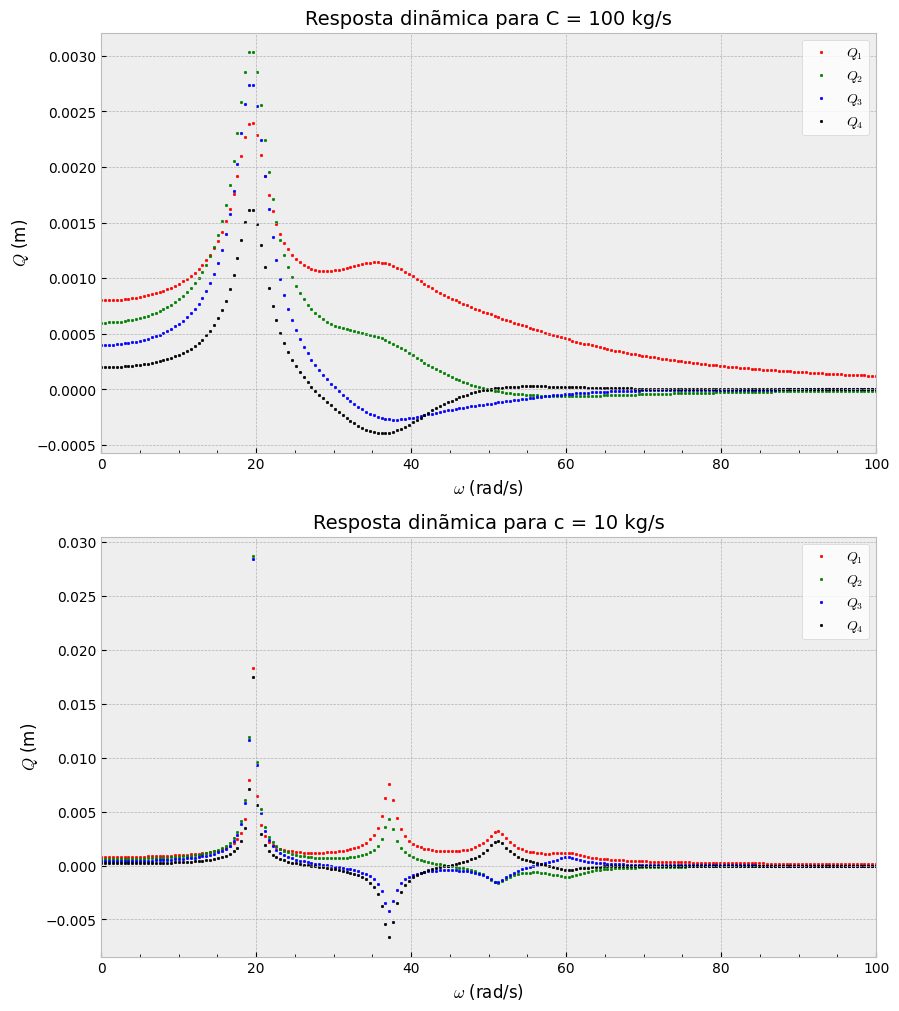

In [44]:
# excitacao harmonica da forma F = [F1,0]*e^(iwt)
F1_ex = 10.0   #N
w_ex = np.linspace(0.0,100.0,200)   #Hz
F_ex = np.array([F1,0.0,0.0,0.0])
#F_ex = np.array([F1,0.0,F1,0.0]) 

M_ex = np.array([[m1,0.0,0.0,0.0],[0.0,m2,0.0,0.0],[0.0,0.0,m3,0.0],[0.0,0.0,0.0,m4]])
K_ex = np.array([[k1+k2,-k2,0.0,0.0],[-k2,k2+k3,-k3,0.0],[0.0,-k3,k3+k4,-k4],[0.0,0.0,-k4,k4+k5]])
C1_ex = np.array([[c1+c2,-c2,0.0,0.0],[-c2,c3+c2,-c3,0.0],[0.0,-c3,c3+c4,-c4],[0.0,0.0,-c4,c4+c5]])
C2_ex = np.array([[c6+c7,-c7,0.0,0.0],[-c7,c8+c7,-c8,0.0],[0.0,-c8,c8+c9,-c9],[0.0,0.0,-c9,c9+c10]])

# construindo uma matriz de amortecimento proporcional
def RMSE(x : list,*args : tuple):
    SE = (args[2] - (x[0]*args[0] + x[1]*args[1]))**2.0
    RMSE = (np.sum(SE)/SE.size)**0.5
    return RMSE

#print(RMSE([0.007,0.01],M,K,C))   #example

optimization1 = optimize.differential_evolution(
               func=RMSE,
               bounds=optimize.Bounds([0.001,0.0001],[100.0,100.0]),
               args=(M_ex,K_ex,C1_ex),
               #x0=[100.0,0.001],
               maxiter=100,
               tol=0.001,
               #polish=False,
               #popsize=20,
               #disp=True
               )

optimization2 = optimize.differential_evolution(
               func=RMSE,
               bounds=optimize.Bounds([0.001,0.0001],[100.0,100.0]),
               args=(M_ex,K_ex,C2_ex),
               #x0=[100.0,0.001],
               maxiter=100,
               tol=0.001,
               #polish=False,
               #popsize=20,
               #disp=True
               )

alpha1, beta1 = optimization1.x
RMSE_final_value1 = optimization1.fun
print("\nalpha: {}\nbeta: {}".format(alpha1,beta1))
print("\nRMSE: {}".format(RMSE_final_value1))

Cp1_ex = alpha1*M_ex + beta1*K_ex

print("\nMatriz de amortecimento proporcional: ")
print(Cp1_ex)

alpha2, beta2 = optimization2.x
RMSE_final_value2 = optimization2.fun
print("\nalpha: {}\nbeta: {}".format(alpha2,beta2))
print("\nRMSE: {}".format(RMSE_final_value2))

Cp2_ex = alpha2*M_ex + beta2*K_ex

print("\nMatriz de amortecimento proporcional: ")
print(Cp2_ex)

# assumindo uma solucao Q = [Q1,Q2]*e^(i(wt + p))

# matriz dinamica
M_ex_inv = np.linalg.inv(M_ex)
D_ex = M_ex_inv@K_ex

# modos de vibração e frequencias naturais
autovalores, autovetores = np.linalg.eig(D_ex)

f_naturais = autovalores**0.5
modos = autovetores

print('\nFrequências naturais e modos de vibração')
print(f_naturais)
print(modos)

# matriz de massa modal e matriz de rigidez modal (desacoplando o sistema)
modos_T = np.transpose(modos)

M_modal = modos_T@M_ex@modos
K_modal = modos_T@K_ex@modos
Cp1_modal = modos_T@Cp1_ex@modos
Cp2_modal = modos_T@Cp2_ex@modos
F_modal = modos_T@F_ex

def R_din(w,M_modal,Cp_modal,K_modal,F_modal):
    Q = np.empty([w.size,M_modal.shape[0]])
    for i in range(w.size):
        Z = np.empty(M_modal.shape[0])
        for j in range(M_modal.shape[0]):
            Z[j] = np.linalg.norm(-w[i]**2.0*M_modal[j,j] + w[i]*Cp_modal[j,j]*1j + K_modal[j,j])
        
        R = Z**(-1.0)
        Q_modal = R*F_modal
        Q[i,:] = modos@Q_modal

    return Q

Q_din_C1 = R_din(w_ex,M_modal,Cp1_modal,K_modal,F_modal)
Q_din_C2 = R_din(w_ex,M_modal,Cp2_modal,K_modal,F_modal)

# plot
plt.style.use('bmh')

fig1, ((ax1),(ax2)) = plt.subplots(2,1, sharey=False, sharex=False, figsize = (10,12))

#ax1.plot(wex,Q_din[:,0], color='red', linewidth=1.0, label=r'$Q_1$')
ax1.scatter(w_ex,Q_din_C1[:,0], color='red', s=3.0, label=r'$Q_1$')
ax1.scatter(w_ex,Q_din_C1[:,1], color='green', s=3.0, label=r'$Q_2$')
ax1.scatter(w_ex,Q_din_C1[:,2], color='blue', s=3.0, label=r'$Q_3$')
ax1.scatter(w_ex,Q_din_C1[:,3], color='black', s=3.0, label=r'$Q_4$')
ax1.set_title('Resposta dinãmica para C = {} kg/s'.format(c1),fontdict={'fontsize':14})
ax1.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax1.set_ylabel('$Q$ (m)',fontdict={'fontsize':12})
ax1.legend(loc='best',facecolor ='w')
ax1.set_xlim(w_ex[0],w_ex[-1])
#ax1.set_ylim(min(Q_din[:,0])*0.8,max(Q_din[:,0])*1.1)
ax1.xaxis.set_minor_locator(MultipleLocator(5))
ax1.yaxis.set_minor_locator(MultipleLocator(0.01))

ax2.scatter(w_ex,Q_din_C2[:,0], color='red', s=3.0, label=r'$Q_1$')
ax2.scatter(w_ex,Q_din_C2[:,1], color='green', s=3.0, label=r'$Q_2$')
ax2.scatter(w_ex,Q_din_C2[:,2], color='blue', s=3.0, label=r'$Q_3$')
ax2.scatter(w_ex,Q_din_C2[:,3], color='black', s=3.0, label=r'$Q_4$')
ax2.set_title('Resposta dinãmica para c = {} kg/s'.format(c6),fontdict={'fontsize':14})
ax2.set_xlabel('$\\omega$ (rad/s)',fontdict={'fontsize':12})
ax2.set_ylabel('$Q$ (m)',fontdict={'fontsize':12})
ax2.legend(loc='best',facecolor ='w')
ax2.set_xlim(w_ex[0],w_ex[-1])
#ax2.set_ylim(min(Q_din[:,0])*0.8,max(Q_din[:,0])*1.1)
ax2.xaxis.set_minor_locator(MultipleLocator(5))
ax2.yaxis.set_minor_locator(MultipleLocator(0.01))


plt.show()